In [ ]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import random
from random import sample

from astroML.datasets import fetch_dr7_quasar # type: ignore

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']


## Rejection sampling 

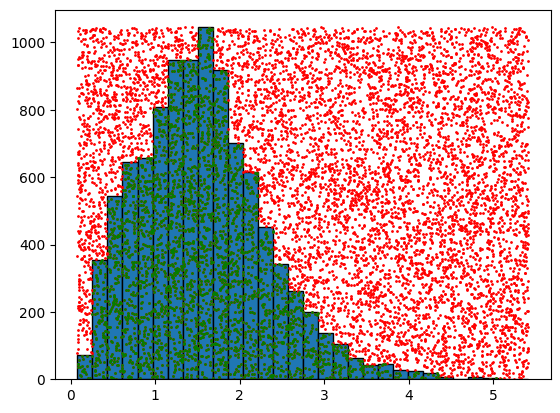

In [26]:
a,b,c=plt.hist(z, bins=30, edgecolor='black') #a are the counts
np.histogram(z, bins=30)

x=np.random.uniform(np.min(z), np.max(z), 10000)
u=np.random.uniform(0, np.max(a), 10000)

plt.scatter(x,u, color='red', s=1)

index=np.searchsorted(b,x)-1 #where x would be inserted in b

values_inside= u <= a[index]

x_i=x[values_inside]
u_i=u[values_inside]

plt.scatter(x_i,u_i, color='green', s=1)

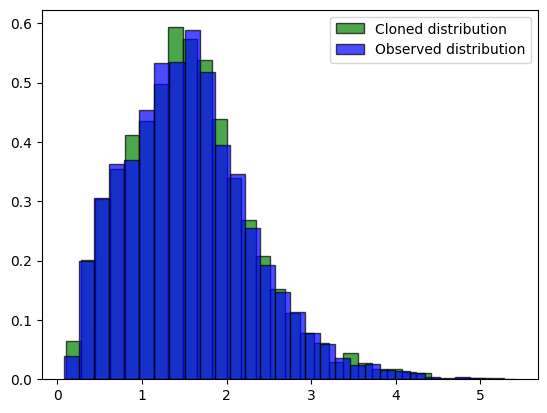

In [14]:
plt.hist(x_i, bins=30, edgecolor='black', color='green', density=True, alpha=0.7, label='Cloned distribution')
plt.hist(z, bins=30, edgecolor='black', color='blue', density=True, alpha=0.7, label='Observed distribution' )
plt.legend()
plt.show()

## Rejection sampling whit a different pdf on x (not uniform)


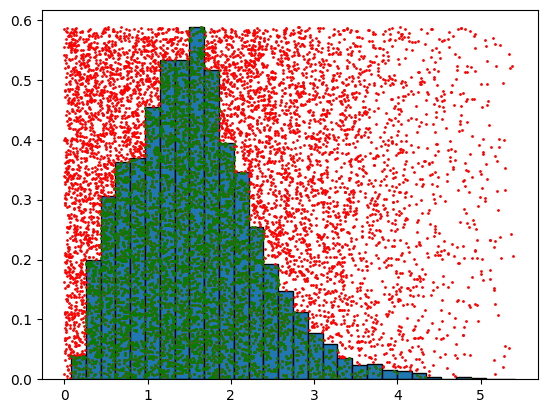

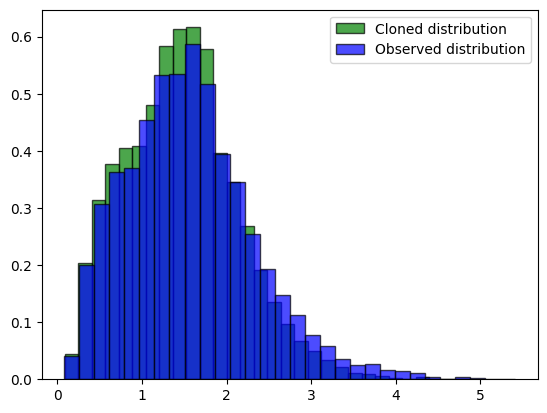

In [33]:
au,bu,c=plt.hist(z, bins=30, edgecolor='black', density=True) #a are the counts

g=abs(np.random.normal(1.6,1.5,10000))
g = g[g < np.max(z)]
u_g=np.random.uniform(0, np.max(au), np.size(g))

plt.scatter(g,u_g, color='red', s=1)

index_g=np.searchsorted(bu,g)-1 #where x would be inserted in b

values_inside_g= u_g <= au[index_g]

g_i=g[values_inside_g]
ug_i=u_g[values_inside_g]

plt.scatter(g_i,ug_i, color='green', s=1)
plt.show()
plt.hist(g_i, bins=30, edgecolor='black', color='green', density=True, alpha=0.7, label='Cloned distribution')
plt.hist(z, bins=30, edgecolor='black', color='blue', density=True, alpha=0.7, label='Observed distribution' )
plt.legend()
plt.show()


## Inverse transform sampling 

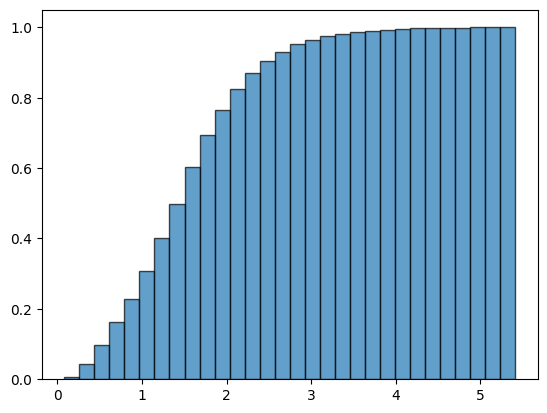

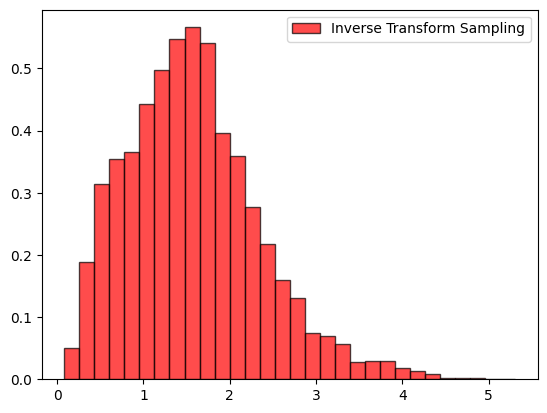

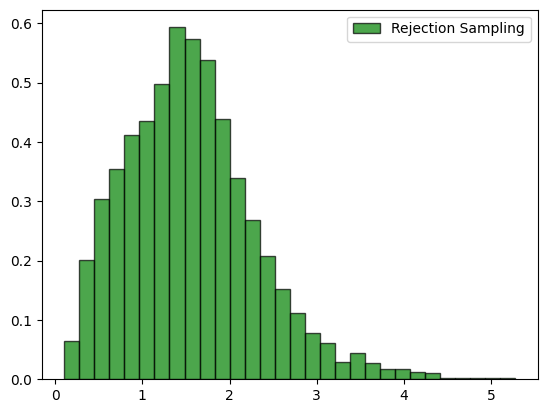

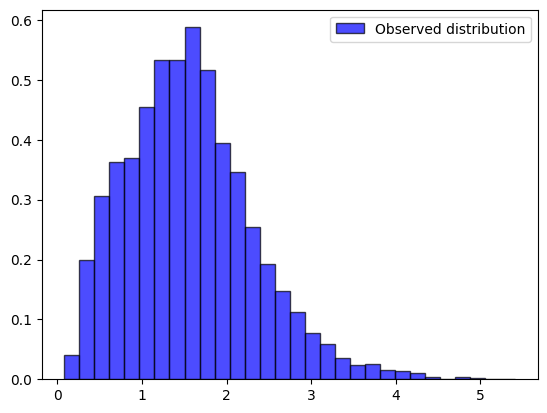

In [16]:
a,b,c=plt.hist(z,30, edgecolor='black', cumulative=True, alpha=0.7, density=True) # a values of cumulative 
plt.show()
y=np.random.uniform(0,1,10000)

index=np.searchsorted(a,y) #where y would be inserted in a

w=np.random.uniform(b[index], b[index+1])


plt.hist(w, bins=30, edgecolor='black', color='red', density=True, alpha=0.7, label='Inverse Transform Sampling')
plt.legend()
plt.show()
plt.hist(x_i, bins=30, edgecolor='black', color='green', density=True, alpha=0.7, label='Rejection Sampling')
plt.legend()
plt.show()
plt.hist(z, bins=30, edgecolor='black', color='blue', density=True, alpha=0.7, label='Observed distribution' )
plt.legend()
